In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, confusion_matrix
data = pd.read_csv('/Users/garimau/dev/dsdp-ucsf/UCSFDelirium/AdmissionGenes/oversampled_admission.csv')



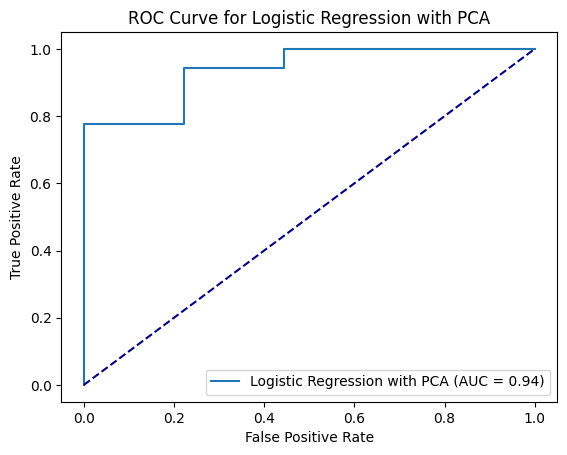

ROC AUC Score: 0.94
Accuracy: 0.89
Confusion Matrix:
[[18  0]
 [ 4 14]]


In [6]:
X = data.drop(columns=['target'], inplace=False)
y = data['target']

X_trainLPCA, X_testLPCA, y_trainLPCA, y_testLPCA = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Apply PCA
pca = PCA(n_components=10, random_state=42)  # Adjust the number of components based on explained variance
X_train_pca = pca.fit_transform(X_trainLPCA)
X_test_pca = pca.transform(X_testLPCA)

# Step 6: Train Logistic Regression Model on PCA-transformed data
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_pca, y_trainLPCA)

# Step 7: Make Predictions and Evaluate Model
y_pred_proba = lr_model.predict_proba(X_test_pca)[:, 1]
y_pred = lr_model.predict(X_test_pca)

# Calculate AUC-ROC score
roc_auc = roc_auc_score(y_testLPCA, y_pred_proba)

# Step 8: Plot the ROC Curve
fpr, tpr, thresholds = roc_curve(y_testLPCA, y_pred_proba)
plt.figure()
plt.plot(fpr, tpr, label=f'Logistic Regression with PCA (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')  # Reference line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression with PCA')
plt.legend(loc='lower right')
plt.show()

# Step 9: Output Additional Metrics
accuracy = accuracy_score(y_testLPCA, y_pred)
conf_matrix = confusion_matrix(y_testLPCA, y_pred)

print(f'ROC AUC Score: {roc_auc:.2f}')
print(f'Accuracy: {accuracy:.2f}')
print('Confusion Matrix:')
print(conf_matrix)

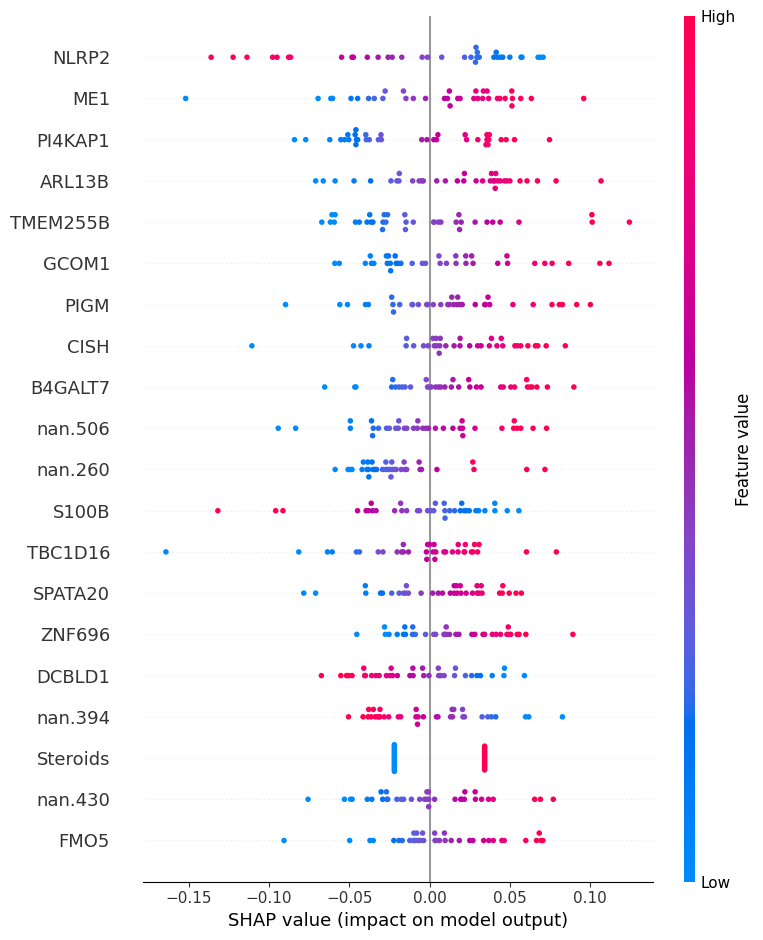

In [7]:
import shap
from sklearn.preprocessing import StandardScaler
#X_trainLPCA, X_testLPCA, y_trainLPCA, y_testLPCA
# Step 9: Standardize the numerical features for SHAP (Optional, depending on the logistic regression convergence)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_trainLPCA), columns=X_trainLPCA.columns, index=X_trainLPCA.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_testLPCA), columns=X_testLPCA.columns, index=X_testLPCA.index)

# Step 10: Fit model on scaled data (replace original model with one trained on scaled data)
lr_model.fit(X_train_scaled, y_trainLPCA)

# Step 11: Initialize SHAP explainer and calculate SHAP values for the test set
explainer = shap.Explainer(lr_model, X_train_scaled)
shap_values = explainer(X_test_scaled)

# Step 12: Plot SHAP Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled, plot_type="dot", show=True)

In [8]:
X_pca = data[X_test_scaled.columns[:750].to_list()]
y_pca = data['target']

In [9]:
X_trainPCA, X_testPCA, y_trainPCA, y_testPCA = train_test_split(X_pca, y_pca, test_size=0.2, random_state=42)


pca = PCA(n_components=10, random_state=42)  # Adjust the number of components based on explained variance
X_train_PCA = pca.fit_transform(X_trainLPCA)
X_test_PCA = pca.transform(X_testLPCA)


/Users/garimau/dev/dsdp-ucsf/UCSFDelirium/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


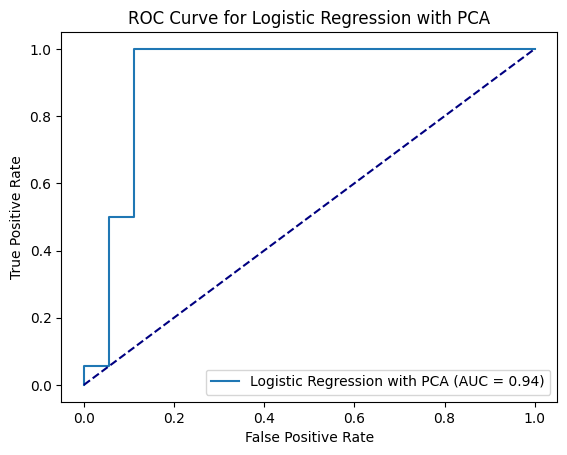

ROC AUC Score: 0.92
Accuracy: 0.89
Confusion Matrix:
[[18  0]
 [ 4 14]]


In [10]:
# Step 6: Train Logistic Regression Model on PCA-transformed data
lr_modelFS = LogisticRegression(random_state=42)
lr_modelFS.fit(X_trainPCA, y_trainLPCA)

# Step 7: Make Predictions and Evaluate Model
y_pred_probaFS = lr_modelFS.predict_proba(X_testPCA)[:, 1]
y_predFS = lr_modelFS.predict(X_testPCA)

# Calculate AUC-ROC score
roc_aucFS = roc_auc_score(y_testPCA, y_pred_probaFS)

# Step 8: Plot the ROC Curve
fpr, tpr, thresholds = roc_curve(y_testPCA, y_pred_probaFS)
plt.figure()
plt.plot(fpr, tpr, label=f'Logistic Regression with PCA (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')  # Reference line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression with PCA')
plt.legend(loc='lower right')
plt.show()

# Step 9: Output Additional Metrics
accuracyFS = accuracy_score(y_testLPCA, y_pred)
conf_matrixFS = confusion_matrix(y_testLPCA, y_pred)

print(f'ROC AUC Score: {roc_aucFS:.2f}')
print(f'Accuracy: {accuracyFS:.2f}')
print('Confusion Matrix:')
print(conf_matrixFS)

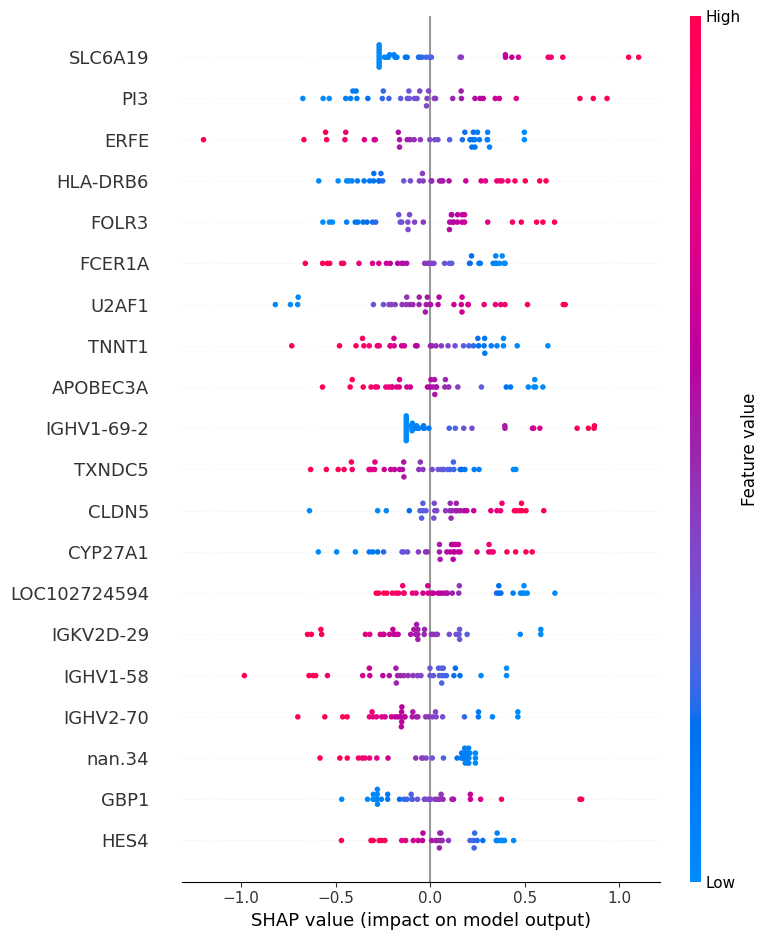

In [11]:
import shap
from sklearn.preprocessing import StandardScaler
#X_trainPCA, X_testPCA, y_trainPCA, y_testPCA
# Step 9: Standardize the numerical features for SHAP (Optional, depending on the logistic regression convergence)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_trainPCA), columns=X_trainPCA.columns, index=X_trainPCA.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_testPCA), columns=X_testPCA.columns, index=X_testPCA.index)

# Step 10: Fit model on scaled data (replace original model with one trained on scaled data)
lr_model.fit(X_train_scaled, y_trainPCA)

# Step 11: Initialize SHAP explainer and calculate SHAP values for the test set
explainer = shap.Explainer(lr_model, X_train_scaled)
shap_values = explainer(X_test_scaled)

# Step 12: Plot SHAP Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_scaled, plot_type="dot", show=True)